# PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import plotly.graph_objects as go
from kneed import KneeLocator
import plotly.io as pio
pio.renderers.default = "vscode"

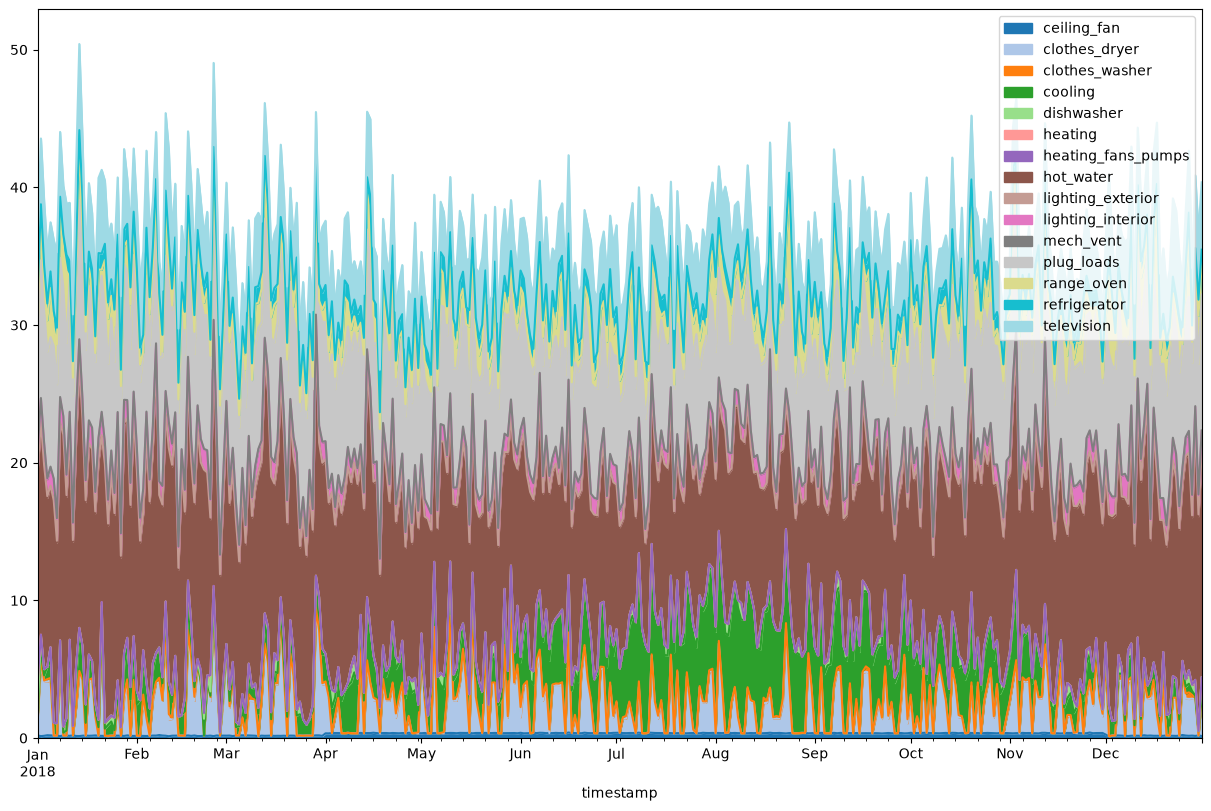

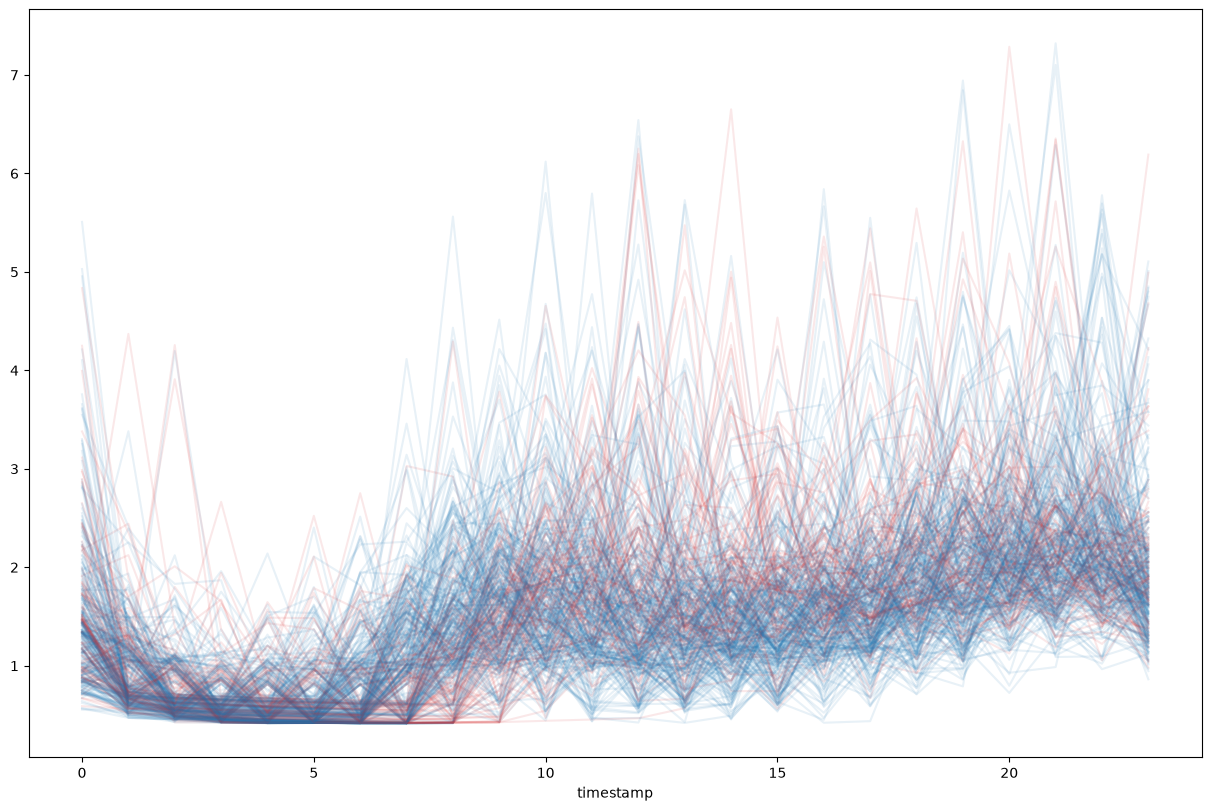

In [2]:
dff = (
     pd.read_parquet("C:/Users/eassoumou1/FlexiMax/data/raw/100276-0.parquet")
       .assign(timestamp=lambda x: x["timestamp"] - pd.Timedelta("15m"))
       .set_index("timestamp")
       .loc[:, lambda x:
x.columns.str.match(r"out\.electricity\..*\.energy_consumption\.\.kwh")]
       .loc[:, lambda x: x.ne(0).any(axis=0)]
       .rename(columns=lambda x: x[16:-24])
       .drop(columns="net")
)

dfh = dff.resample("h").sum()
dfd = dfh.resample("D").sum()

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
dfd.drop(columns="total").plot(ax=ax, kind="area", cmap="tab20")
plt.legend(loc="upper right")
plt.show()
plt.close(fig)

piv = dfh.pivot_table(index=dfh.index.normalize(),
columns=dfh.index.hour, values="total")
cmap = (piv.index.day_of_week // 5).map({0: "tab:blue", 1: "tab:red"})
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
piv.T.plot(ax=ax, color=cmap, alpha=0.1, legend=False)
plt.show()

In [3]:
piv

timestamp,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.85191,1.01072,0.96792,0.42196,0.41709,0.41864,0.41697,1.86916,2.25076,1.23566,...,1.11590,2.82703,2.09999,1.69789,2.37634,2.60933,3.81705,1.89853,2.41133,2.19863
2018-01-02,1.34509,0.83864,1.71675,0.45308,0.91959,1.32005,0.88697,1.74683,4.30753,1.73265,...,3.71940,1.31273,1.73931,1.42297,2.01354,2.22964,2.05833,2.08814,1.76709,1.90975
2018-01-03,5.50700,1.30829,1.03653,0.46018,0.83790,0.42120,0.41729,0.41667,0.43263,2.77029,...,1.18832,0.99422,0.96424,2.40433,1.55478,1.52530,1.52446,1.95708,2.46375,2.29523
2018-01-04,1.23420,0.81508,0.48686,0.42345,0.41876,0.81407,0.41680,0.41600,0.61370,3.44364,...,1.00649,1.48069,4.72198,1.92036,1.48928,1.22818,1.28146,1.68478,2.24787,2.04915
2018-01-05,1.68483,1.37109,0.51716,0.42852,0.56240,0.79099,0.41729,0.41673,0.41966,0.81665,...,1.25091,1.10084,5.09824,2.92324,2.87783,3.02834,2.71892,2.36324,1.93175,1.87243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,1.63688,1.23246,0.94818,0.84775,0.43868,0.43557,1.66866,0.42177,1.13393,0.43123,...,4.12175,1.05657,1.78638,1.49027,1.28171,1.78668,1.79192,3.25935,2.33994,2.84959
2018-12-28,1.43451,0.77659,1.10844,0.42339,0.41863,0.42046,0.98125,0.41534,1.20261,0.62333,...,1.25186,1.02911,1.25934,2.09075,2.02090,2.32283,1.65597,1.70651,2.69610,4.66663
2018-12-29,1.98611,0.71051,0.48861,0.85784,0.67414,1.78830,1.56078,0.41664,0.41883,0.99383,...,2.29803,2.00084,2.35659,1.34824,3.77822,2.52994,3.47225,2.14704,1.42848,1.79070


In [4]:
features = piv.columns
x = piv[features].values
x

array([[0.85191  , 1.01072  , 0.96792  , ..., 1.89853  , 2.41133  ,
        2.19863  ],
       [1.34509  , 0.83864  , 1.71675  , ..., 2.08814  , 1.7670901,
        1.90975  ],
       [5.507    , 1.30829  , 1.03653  , ..., 1.95708  , 2.4637501,
        2.29523  ],
       ...,
       [1.98611  , 0.71051  , 0.48861  , ..., 2.14704  , 1.42848  ,
        1.7907   ],
       [1.8299301, 0.5843   , 1.01695  , ..., 2.21185  , 2.1840901,
        2.56003  ],
       [2.25608  , 1.13735  , 1.33981  , ..., 2.55423  , 3.22537  ,
        2.10942  ]], shape=(365, 24), dtype=float32)

In [5]:
X = StandardScaler().fit_transform(x) 
X

array([[-0.85939026,  0.1412476 ,  0.48753628, ..., -0.44966763,
         0.1788456 ,  0.2372706 ],
       [-0.22624594, -0.24934153,  2.2502043 , ..., -0.2457207 ,
        -0.6039366 , -0.12053573],
       [ 5.1168127 ,  0.8166752 ,  0.6490371 , ..., -0.3866905 ,
         0.24253857,  0.35691893],
       ...,
       [ 0.59669524, -0.5401723 , -0.64070964, ..., -0.18236725,
        -1.015364  , -0.26799086],
       [ 0.3961915 , -0.8266452 ,  0.60294783, ..., -0.11265675,
        -0.09726166,  0.68489975],
       [ 0.94328254,  0.42867362,  1.3629267 , ...,  0.25561157,
         1.167943  ,  0.12677522]], shape=(365, 24), dtype=float32)

### Visualisation graphique avec une PCA en 2D (2 composantes)

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca

array([[ 8.82475555e-01,  3.38324428e-01],
       [ 1.46889246e+00,  6.12209201e-01],
       [-1.87488186e+00, -1.50094759e+00],
       [-7.69256234e-01, -7.62588799e-01],
       [-2.10689545e+00,  1.13485920e+00],
       [-9.20945585e-01, -1.54538429e+00],
       [-9.34824407e-01, -3.93449038e-01],
       [-1.49356306e+00, -3.06330824e+00],
       [ 2.17366628e-02, -1.47544920e+00],
       [-1.70577621e+00,  1.25186015e-02],
       [-1.10231471e+00, -2.40363812e+00],
       [ 1.06126463e+00, -1.17534542e+00],
       [-2.75430346e+00,  2.25801468e-02],
       [-7.19610631e-01, -1.61592376e+00],
       [-2.77995896e+00,  8.69568765e-01],
       [-1.36058402e+00,  7.37433732e-01],
       [-1.13091838e+00,  8.29217196e-01],
       [-6.84547782e-01,  2.36088991e-01],
       [ 9.02130544e-01,  8.46917629e-01],
       [-2.29187799e+00, -2.83228517e-01],
       [-1.92058551e+00,  1.17330000e-01],
       [-1.90720880e+00, -1.54788184e+00],
       [ 1.05817102e-01, -4.75247532e-01],
       [-1.

In [7]:
cols = features[:len(X_pca[0])]
df_pca = pd.DataFrame(data=X_pca, columns=cols, index=piv.index)
df_pca

timestamp,0,1
timestamp,,
2018-01-01,0.882476,0.338324
2018-01-02,1.468892,0.612209
2018-01-03,-1.874882,-1.500948
2018-01-04,-0.769256,-0.762589
2018-01-05,-2.106895,1.134859
...,...,...
2018-12-27,-2.439645,-1.113344
2018-12-28,-0.304656,-0.002176
2018-12-29,-1.362657,2.157669


In [8]:
var_expliquee = pca.explained_variance_ratio_

print(f"Variance expliquée par la 1ere composante : {var_expliquee[0]*100:.2f}%")
print(f"Variance expliquée par la 2e composante : {var_expliquee[1]*100:.2f}%")
print(f"Variance totale conservée : {sum(var_expliquee)*100:.2f}%")

Variance expliquée par la 1ere composante : 8.72%
Variance expliquée par la 2e composante : 7.21%
Variance totale conservée : 15.93%


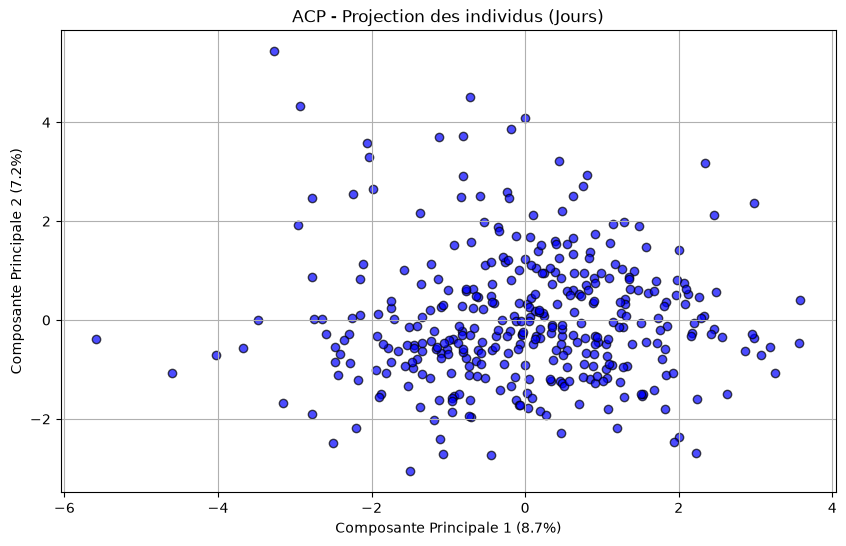

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pca[0], df_pca[1], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'Composante Principale 1 ({var_expliquee[0]*100:.1f}%)')
plt.ylabel(f'Composante Principale 2 ({var_expliquee[1]*100:.1f}%)')
plt.title('ACP - Projection des individus (Jours)')
plt.grid(True)
plt.show()


In [10]:
df_coefs = pd.DataFrame(pca.components_[:2, :], columns=features, index=['0', '1'])

print("     TABLEAU DES COEFFICIENTS")
print(df_coefs.T)

     TABLEAU DES COEFFICIENTS
                  0         1
timestamp                    
0         -0.220724 -0.076177
1         -0.346549  0.085380
2         -0.067517  0.284495
3         -0.063793  0.443610
4          0.063228  0.372509
5          0.044110  0.429345
6          0.285512  0.150094
7          0.424872 -0.003961
8          0.364543 -0.138812
9          0.188818 -0.236952
10        -0.074045 -0.237764
11        -0.175486 -0.241574
12        -0.197376 -0.129354
13        -0.186520 -0.275490
14        -0.301566 -0.077827
15        -0.290327  0.112219
16        -0.172396  0.104714
17        -0.144588  0.068857
18        -0.099395  0.180817
19         0.058334  0.051344
20        -0.067644 -0.031234
21        -0.109257  0.054019
22        -0.037489  0.069428
23        -0.137670  0.046939


In [11]:
def afficher_formule_pc(pca_obj, feature_names, pc_index=0):
    coefs = pca_obj.components_[pc_index]
    termes = []
    for coef, nom in zip(coefs, feature_names):
        signe = "+" if coef >= 0 else "-"
        termes.append(f"{signe} {abs(coef):.3f} * {nom}")
    equation = f"{pc_index + 1}ère composante = " + " ".join(termes)
    return equation

print("FORMULES EXPLICITES")
print(afficher_formule_pc(pca, features, pc_index=0))  
print(afficher_formule_pc(pca, features, pc_index=1))  # Formule PC2

FORMULES EXPLICITES
1ère composante = - 0.221 * 0 - 0.347 * 1 - 0.068 * 2 - 0.064 * 3 + 0.063 * 4 + 0.044 * 5 + 0.286 * 6 + 0.425 * 7 + 0.365 * 8 + 0.189 * 9 - 0.074 * 10 - 0.175 * 11 - 0.197 * 12 - 0.187 * 13 - 0.302 * 14 - 0.290 * 15 - 0.172 * 16 - 0.145 * 17 - 0.099 * 18 + 0.058 * 19 - 0.068 * 20 - 0.109 * 21 - 0.037 * 22 - 0.138 * 23
2ère composante = - 0.076 * 0 + 0.085 * 1 + 0.284 * 2 + 0.444 * 3 + 0.373 * 4 + 0.429 * 5 + 0.150 * 6 - 0.004 * 7 - 0.139 * 8 - 0.237 * 9 - 0.238 * 10 - 0.242 * 11 - 0.129 * 12 - 0.275 * 13 - 0.078 * 14 + 0.112 * 15 + 0.105 * 16 + 0.069 * 17 + 0.181 * 18 + 0.051 * 19 - 0.031 * 20 + 0.054 * 21 + 0.069 * 22 + 0.047 * 23


### PCA avec un nombre de variables standardisées permettant d'expliquer 95% de la variance

In [12]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
X_pca

array([[ 0.88247555,  0.33832443,  2.0918748 , ..., -0.3915337 ,
        -0.43093666, -0.24523361],
       [ 1.4688925 ,  0.6122092 , -1.131164  , ...,  1.6226227 ,
        -1.1879143 ,  0.35574943],
       [-1.8748819 , -1.5009476 , -3.1574554 , ...,  0.33533603,
        -0.5892217 , -0.42233187],
       ...,
       [-1.3626568 ,  2.1576686 ,  1.1692272 , ...,  0.37672156,
         0.94498277,  0.6557165 ],
       [-0.6360009 ,  0.47692835,  0.96698815, ...,  0.20942646,
         0.15465993, -0.15491219],
       [-2.2601469 ,  0.03695271, -2.42767   , ...,  0.38684043,
         0.56415343, -0.87307996]], shape=(365, 22), dtype=float32)

In [13]:
print("Nombre de variables avant la PCA : "+str(len(X[0])))
print("Nombre de variables après la PCA en gardant 95%"+" de l'information: "+str(len(X_pca[0])))

Nombre de variables avant la PCA : 24
Nombre de variables après la PCA en gardant 95% de l'information: 22


In [14]:
cols = features[:len(X_pca[0])]
df_pca = pd.DataFrame(data=X_pca, columns=cols, index=piv.index)
df_pca

timestamp,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.882476,0.338324,2.091875,1.498199,0.197177,-0.833829,-0.660653,-1.894628,0.738491,1.057585,...,0.339425,1.280828,0.826406,-0.167309,1.004865,-1.242479,0.093738,-0.391534,-0.430937,-0.245234
2018-01-02,1.468892,0.612209,-1.131164,-1.316486,2.504822,0.998489,-0.997788,-1.048274,1.501418,-1.523346,...,1.314998,1.548250,2.282469,1.715250,-0.313690,-0.268918,0.584962,1.622623,-1.187914,0.355749
2018-01-03,-1.874882,-1.500948,-3.157455,0.710379,-1.173022,-0.865362,-1.373663,1.596292,-3.006585,-0.313199,...,1.014209,1.195382,-1.259735,-0.699565,-0.112869,1.486302,-1.551168,0.335336,-0.589222,-0.422332
2018-01-04,-0.769256,-0.762589,0.703682,-2.479572,-1.596092,-0.736210,-0.716681,0.094266,-0.364830,2.061538,...,1.384492,1.327005,-0.391915,-0.191323,-1.798290,-0.182186,1.846121,0.407684,1.763910,0.618358
2018-01-05,-2.106895,1.134859,3.122421,-0.813191,-1.117563,-1.587694,0.877265,-0.185241,-1.342232,0.399193,...,1.396073,0.544461,-0.011825,-0.260765,-2.502137,-0.622391,1.624374,-0.248335,0.022677,0.700158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,-2.439645,-1.113344,-1.609770,-0.072400,0.753805,2.217726,1.582083,0.785816,1.135704,-0.448741,...,0.225016,-2.434176,0.926226,0.561283,-0.492248,1.132936,1.748776,0.501619,-0.515325,-0.630156
2018-12-28,-0.304656,-0.002176,-0.488506,0.987683,-1.659681,-1.805685,0.013386,1.834010,1.369686,0.875210,...,-0.668985,-0.743217,1.480670,1.162635,-0.207050,-0.122667,0.023090,-0.658295,-0.310853,0.519330
2018-12-29,-1.362657,2.157669,1.169227,-1.348546,1.785406,-0.189669,3.074851,1.074972,-0.679250,-0.240333,...,0.069093,-0.480400,0.895756,-1.392774,0.562863,-0.264526,0.025763,0.376722,0.944983,0.655716


In [15]:
var_expliquee = pca.explained_variance_ratio_

print(f"Variance expliquée par la 1ere composante : {var_expliquee[0]*100:.2f}%")
print(f"Variance expliquée par la 2e composante : {var_expliquee[1]*100:.2f}%")
print(f"Variance expliquée par la dernière composante : {var_expliquee[len(X_pca[0])-1]*100:.2f}%")
print(f"Variance totale conservée : {sum(var_expliquee)*100:.2f}%")

Variance expliquée par la 1ere composante : 8.72%
Variance expliquée par la 2e composante : 7.21%
Variance expliquée par la dernière composante : 2.24%
Variance totale conservée : 95.84%


### PCA avec un nombre de variables NON standardisées permettant d'expliquer 95% de la variance

In [16]:
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x)

print("Nombre de variables avant la PCA : "+str(len(x[0])))
print("Nombre de variables après la PCA en gardant 95%"+" de l'information: "+str(len(x_pca[0])))

cols = features[:len(x_pca[0])]
df_pca = pd.DataFrame(data=x_pca, columns=cols, index=piv.index)

var_expliquee = pca.explained_variance_ratio_

print(f"Variance expliquée par la 1ere composante : {var_expliquee[0]*100:.2f}%")
print(f"Variance expliquée par la 2e composante : {var_expliquee[1]*100:.2f}%")
print(f"Variance expliquée par la dernière composante : {var_expliquee[len(x_pca[0])-1]*100:.2f}%")
print(f"Variance totale conservée : {sum(var_expliquee)*100:.2f}%")

Nombre de variables avant la PCA : 24
Nombre de variables après la PCA en gardant 95% de l'information: 19
Variance expliquée par la 1ere composante : 10.32%
Variance expliquée par la 2e composante : 8.86%
Variance expliquée par la dernière composante : 1.65%
Variance totale conservée : 95.80%


### Evaluation de l'efficacité de la PCA dans le clustering 

In [17]:
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

df_metadata = pd.read_parquet(DATA_PROCESSED / 'metadata_features.parquet')
df = pd.read_parquet(DATA_RAW / "347201-0.parquet")
df.head()

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
0,347201,2018-01-01 00:15:00,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.222,0.0,0.0,1.0,NaN,0.716,0.2050,0.0,NaN,0.0
1,347201,2018-01-01 00:30:00,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122,0.0,0.0,1.0,NaN,0.701,0.0954,0.0,NaN,0.0
2,347201,2018-01-01 00:45:00,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122,0.0,0.0,1.0,NaN,0.701,0.0954,0.0,NaN,0.0
3,347201,2018-01-01 01:00:00,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122,0.0,0.0,1.0,NaN,0.701,0.0954,0.0,NaN,0.0
4,347201,2018-01-01 01:15:00,322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.113,0.0,0.0,1.0,NaN,0.701,0.0856,0.0,NaN,0.0


            Code de Yassmin, modifié pour s'appliquer à des colonnes par heure et pas par quart-d'heure

Visualisation des clusters de données SANS PCA

k= 2 | inertia=    4212.2 | silhouette=0.1021
k= 3 | inertia=    3994.8 | silhouette=0.0782
k= 4 | inertia=    3845.6 | silhouette=0.0918
k= 5 | inertia=    3697.5 | silhouette=0.0784
k= 6 | inertia=    3569.3 | silhouette=0.0562
k= 7 | inertia=    3449.5 | silhouette=0.0711
k= 8 | inertia=    3325.0 | silhouette=0.0737
k= 9 | inertia=    3233.2 | silhouette=0.0847
k=10 | inertia=    3114.7 | silhouette=0.0863
k=11 | inertia=    3054.6 | silhouette=0.0629
k=12 | inertia=    2985.8 | silhouette=0.0786
k=13 | inertia=    2908.9 | silhouette=0.0611
k=14 | inertia=    2852.9 | silhouette=0.0842
K optimal selon la méthode du coude : k = 10


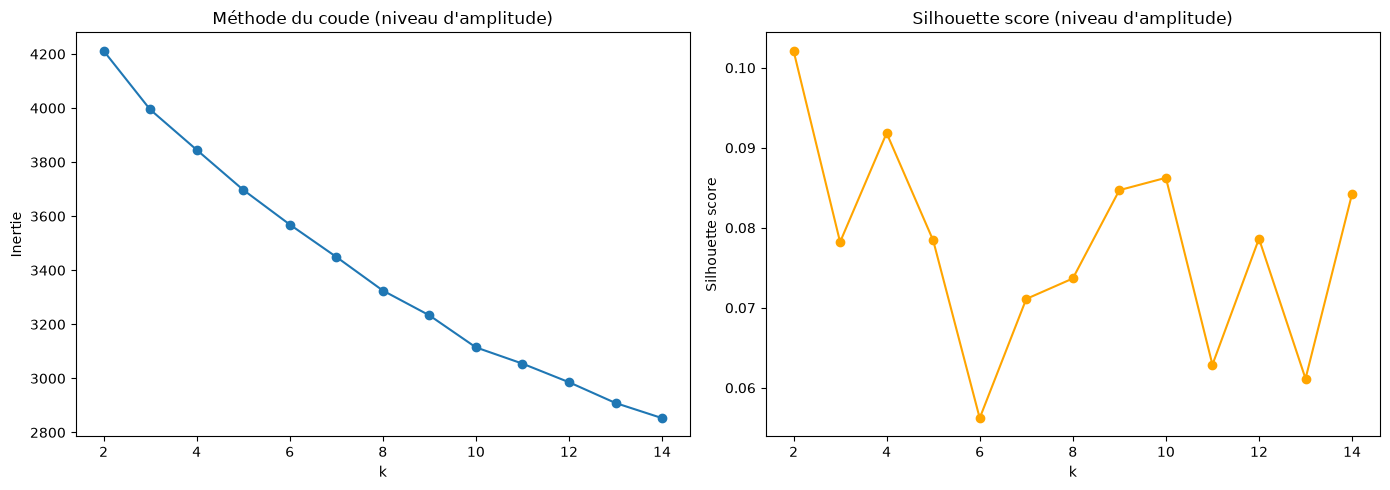

k= 2 | inertia=    8260.7 | silhouette=0.0588
k= 3 | inertia=    7916.7 | silhouette=0.0486
k= 4 | inertia=    7677.9 | silhouette=0.0355
k= 5 | inertia=    7460.1 | silhouette=0.0417
k= 6 | inertia=    7254.1 | silhouette=0.0517
k= 7 | inertia=    7092.4 | silhouette=0.0430
k= 8 | inertia=    6886.0 | silhouette=0.0373
k= 9 | inertia=    6714.4 | silhouette=0.0268
k=10 | inertia=    6644.8 | silhouette=0.0411
k=11 | inertia=    6455.9 | silhouette=0.0431
k=12 | inertia=    6381.9 | silhouette=0.0414
k=13 | inertia=    6214.6 | silhouette=0.0377
k=14 | inertia=    6069.8 | silhouette=0.0568
Aucun coude n'a été détecté
K optimal sélectionné grâce au meilleur score de silhouette : k = 2


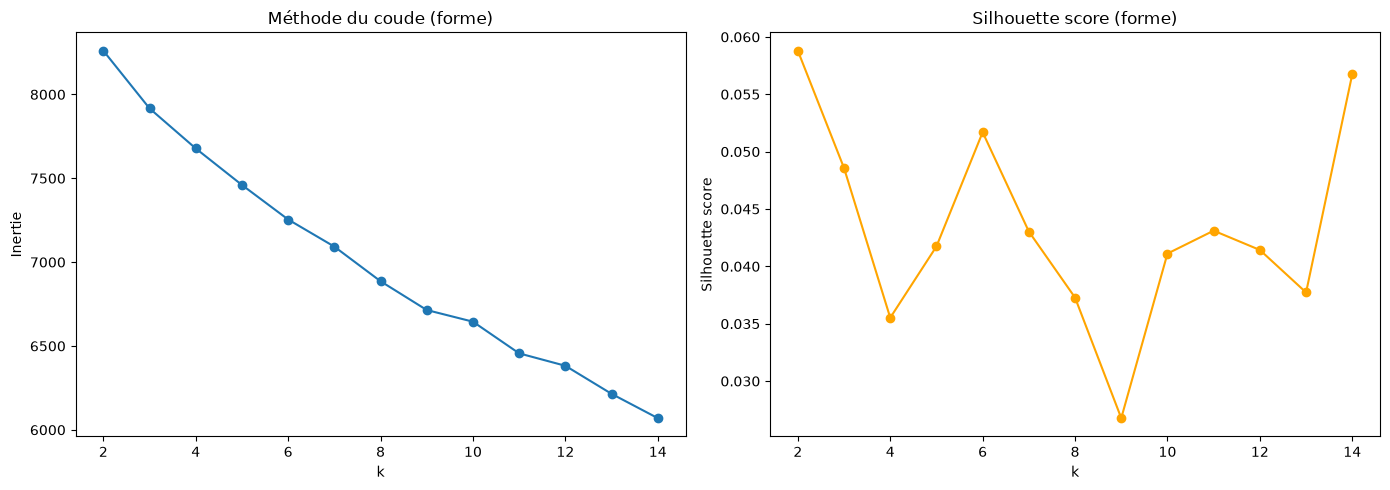

In [40]:
def plot_cluster_profiles(X, title1,title2):

    k_range = range(2, 15)
    inertias = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, labels, sample_size=5000, random_state=42)  # sample_size pour accélérer si beaucoup de jours
        silhouettes.append(sil)
        print(f"k={k:2d} | inertia={km.inertia_:10.1f} | silhouette={sil:.4f}")
    k_opt = KneeLocator(
    list(k_range),
    inertias,
    curve="convex",
    direction="decreasing"
    ).elbow

    if k_opt is None:       #rajouté parce que sur les valeurs standardisées, k_opt=None
        best_idx = np.argmax(silhouettes)   #indice de la valeur maximale dans la liste silouhettes (maximise le score)
        k_opt = list(k_range)[best_idx]
        print(f"Aucun coude n'a été détecté")
        print(f"K optimal sélectionné grâce au meilleur score de silhouette : k = {k_opt}")
    else:
        print(f"K optimal selon la méthode du coude : k = {k_opt}")   

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(list(k_range), inertias, marker='o')
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertie")
    axes[0].set_title(title1)

    axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette score")
    axes[1].set_title(title2)

    plt.tight_layout()
    plt.savefig(FIGURES / "kmeans_elbow_silhouette.png", dpi=150)
    plt.show()
    return k_opt

#Coude sur données brutes
k_amplet=plot_cluster_profiles(x, "Méthode du coude (niveau d'amplitude)", "Silhouette score (niveau d'amplitude)")
#Coude sur données normalisées
k_forme=plot_cluster_profiles(X, "Méthode du coude (forme)", "Silhouette score (forme)")

In [19]:
def cluster_days(k, X_data, dates):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_data)

    results = pd.DataFrame({
        "date": dates,
        "cluster": cluster_labels
    })

    results["weekday"] = results["date"].dt.day_name()
    results["is_weekend"] = results["date"].dt.dayofweek >= 5
    results["month"] = results["date"].dt.month

    print(f"Répartition des données pour k={k}")
    print(results["cluster"].value_counts().sort_index())

    return kmeans, cluster_labels, results

kmeans_forme, cluster_labels_forme, results_forme = cluster_days(k_forme, X,piv.index)

Répartition des données pour k=2
cluster
0    200
1    165
Name: count, dtype: int64


In [20]:
results_forme

,date,cluster,weekday,is_weekend,month
0,2018-01-01,0,Monday,False,1
1,2018-01-02,0,Tuesday,False,1
2,2018-01-03,1,Wednesday,False,1
3,2018-01-04,1,Thursday,False,1
4,2018-01-05,1,Friday,False,1
...,...,...,...,...,...
360,2018-12-27,1,Thursday,False,12
361,2018-12-28,1,Friday,False,12
362,2018-12-29,1,Saturday,True,12
363,2018-12-30,1,Sunday,True,12


In [21]:
kmeans_amplet, cluster_labels_amplet, results_amplet = cluster_days(k_amplet, x,piv.index)
results_amplet

Répartition des données pour k=10
cluster
0     18
1     32
2     20
3     19
4    109
5     41
6     36
7     26
8     25
9     39
Name: count, dtype: int64


,date,cluster,weekday,is_weekend,month
0,2018-01-01,4,Monday,False,1
1,2018-01-02,9,Tuesday,False,1
2,2018-01-03,1,Wednesday,False,1
3,2018-01-04,9,Thursday,False,1
4,2018-01-05,6,Friday,False,1
...,...,...,...,...,...
360,2018-12-27,5,Thursday,False,12
361,2018-12-28,0,Friday,False,12
362,2018-12-29,5,Saturday,True,12
363,2018-12-30,6,Sunday,True,12


In [36]:
def plot_interactive_cluster_profiles(X, cluster_labels, k_final, titre):

    X_arr = np.asarray(X)
    n_steps = X_arr.shape[1]
    hours = np.linspace(0, 23, n_steps)

    fig = go.Figure()

    # Traces
    for c in range(k_final):
        mask = (cluster_labels == c)
        
        # Sécurité si un cluster est vide
        if not np.any(mask):
            continue

        cluster_profiles = X_arr[mask]
        mean_profile = cluster_profiles.mean(axis=0)
        std_profile = cluster_profiles.std(axis=0)

        # Courbe moyenne
        fig.add_trace(
            go.Scatter(
                x=hours,
                y=mean_profile,
                mode="lines",
                name=f"Cluster {c} (n={mask.sum()})",
                visible=(c == 0),
                line=dict(width=3)
            )
        )

        # Zone ±1σ
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([hours, hours[::-1]]),
                y=np.concatenate([
                    mean_profile + std_profile,
                    (mean_profile - std_profile)[::-1]
                ]),
                fill="toself",
                mode="lines",
                opacity=0.15,
                name=f"Std Cluster {c}",
                visible=(c == 0),
                showlegend=False,
                hoverinfo="skip"
            )
        )

    # Boutons
    buttons = []

    for c in range(k_final):
        visibility = []
        for i in range(k_final):
            # Chaque cluster possède 2 traces (courbe + ombre)
            visibility += [i == c, i == c]

        buttons.append(
            dict(
                label=f"Cluster {c}",
                method="update",
                args=[
                    {"visible": visibility},
                    {"title": f"{titre} - Cluster {c}"}
                ]
            )
        )

    # Afficher tous les clusters
    buttons.append(
        dict(
            label="Tous les clusters",
            method="update",
            args=[
                {"visible": [True] * (2 * k_final)},
                {"title": f"{titre} (k={k_final})"}
            ]
        )
    )

    fig.update_layout(
        title=titre,
        xaxis=dict(
            title="Heure de la journée (h)",
            dtick=2 
        ),
        yaxis_title="Consommation / Valeur",
        template="plotly_white",
        width=1000,
        height=600,
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                x=1.05,
                y=1,
                showactive=True
            )
        ]
    )

    fig.show()
    return


print("DONNEES BRUTES")
plot_interactive_cluster_profiles(
    X=x,
    cluster_labels=cluster_labels_amplet,
    k_final=k_amplet,
    titre="Profil journalier par rapport à la quantité d'énergie consommée (amplitude/brut)"
)

print("DONNEES NORMALISEES")
plot_interactive_cluster_profiles(
    X=X,
    cluster_labels=cluster_labels_forme,
    k_final=k_forme,
    titre="Profil journalier par rapport à la forme d'énergie consommée (forme/normalisé)"
)

DONNEES BRUTES


DONNEES NORMALISEES


DONNEES BRUTES
Répartition semaine / weekend :
         Semaine (%)  Weekend (%)
cluster                          
0               66.7         33.3
1               90.6          9.4
2              100.0          0.0
3               68.4         31.6
4               82.6         17.4
5               34.1         65.9
6               69.4         30.6
7               61.5         38.5
8               68.0         32.0
9               64.1         35.9



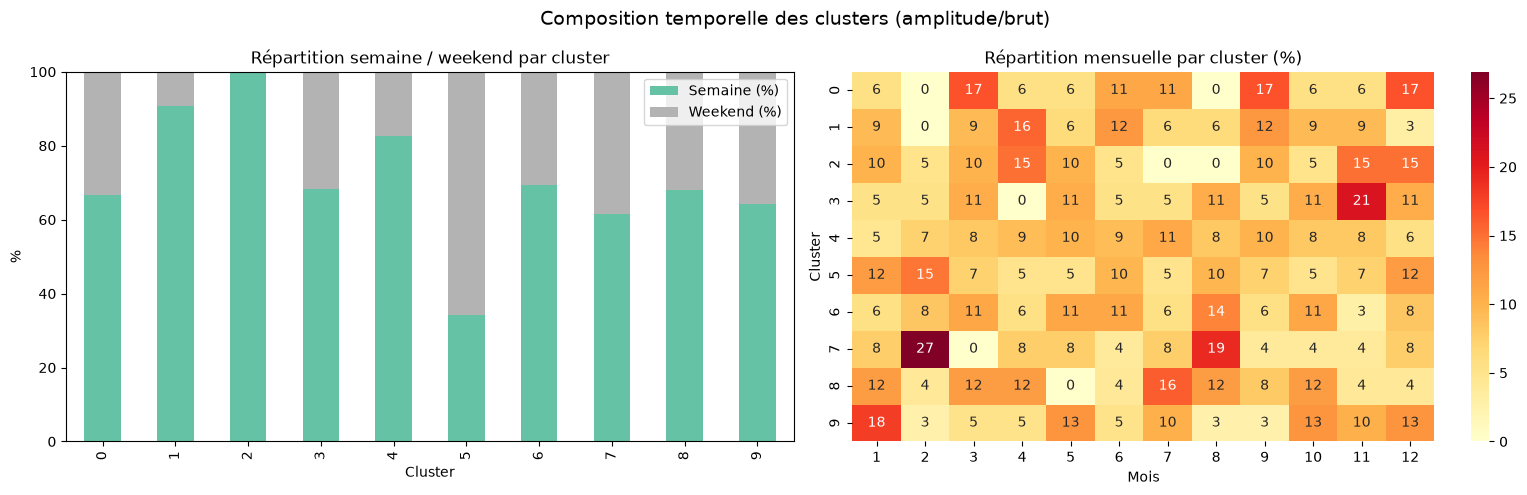

DONNEES NORMALISEES
Répartition semaine / weekend :
         Semaine (%)  Weekend (%)
cluster                          
0               87.0         13.0
1               52.7         47.3



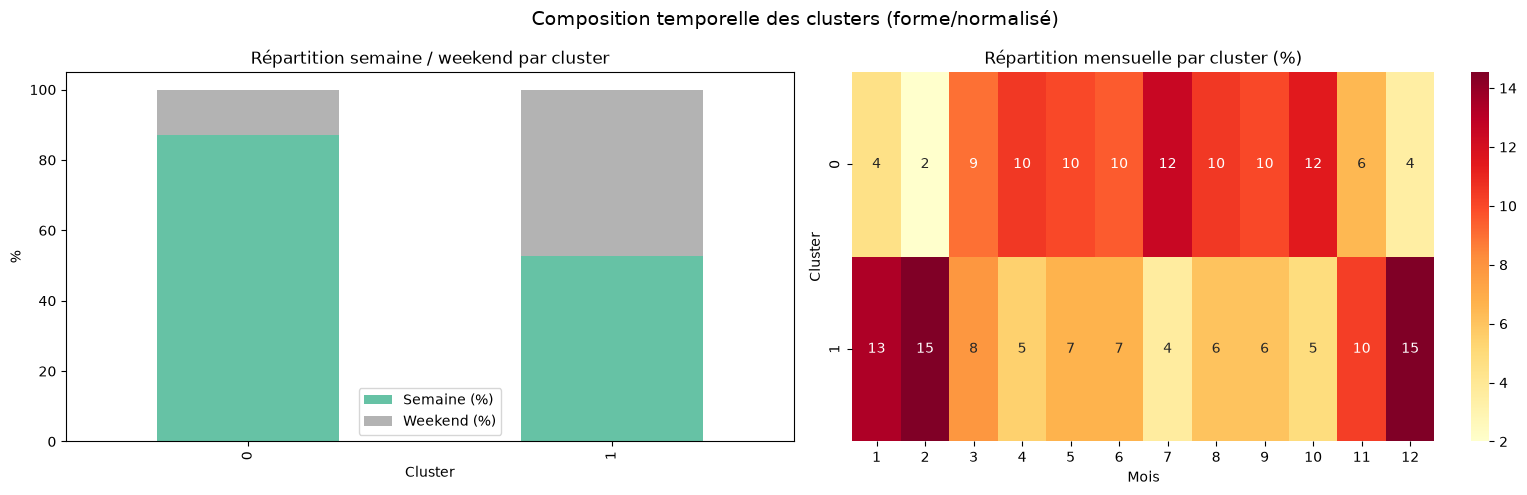

(         Semaine (%)  Weekend (%)
 cluster                          
 0          87.000000    13.000000
 1          52.727273    47.272727,
 month           1          2         3          4          5         6   \
 cluster                                                                   
 0         4.500000   2.000000  9.000000  10.500000  10.000000  9.500000   
 1        13.333333  14.545455  7.878788   5.454545   6.666667  6.666667   
 
 month           7          8          9          10        11         12  
 cluster                                                                   
 0        12.500000  10.500000  10.000000  11.500000   6.50000   3.500000  
 1         3.636364   6.060606   6.060606   4.848485  10.30303  14.545455  )

In [23]:
def plot_cluster_calendar_composition(results, titre):

    # Répartition semaine vs weekend
    comp_weekend = pd.crosstab(
        results["cluster"], 
        results["is_weekend"], 
        normalize="index"
    ) * 100

    comp_weekend.columns = ["Semaine (%)", "Weekend (%)"]

    print("Répartition semaine / weekend :")
    print(comp_weekend.round(1))
    print()

    # Répartition par mois
    comp_month = pd.crosstab(
        results["cluster"], 
        results["month"], 
        normalize="index"
    ) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Weekend
    comp_weekend.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        colormap="Set2"
    )

    axes[0].set_title("Répartition semaine / weekend par cluster")
    axes[0].set_ylabel("%")
    axes[0].set_xlabel("Cluster")
    axes[0].legend(title="")

    # Mois
    sns.heatmap(
        comp_month,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        ax=axes[1]
    )

    axes[1].set_title("Répartition mensuelle par cluster (%)")
    axes[1].set_xlabel("Mois")
    axes[1].set_ylabel("Cluster")

    fig.suptitle(titre, fontsize=14)

    plt.tight_layout()
    plt.savefig(
        FIGURES / "cluster_calendar_composition.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    return comp_weekend, comp_month

print("DONNEES BRUTES")
plot_cluster_calendar_composition(results_amplet, "Composition temporelle des clusters (amplitude/brut)")
print("DONNEES NORMALISEES")
plot_cluster_calendar_composition(results_forme, "Composition temporelle des clusters (forme/normalisé)")

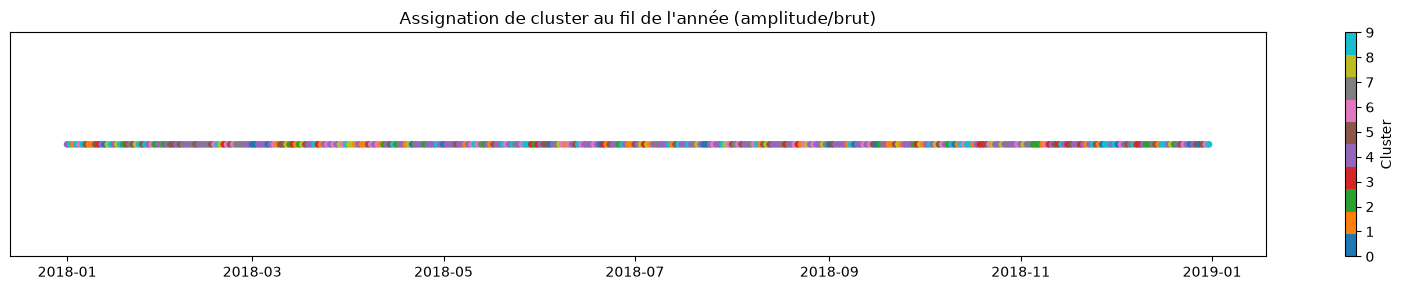

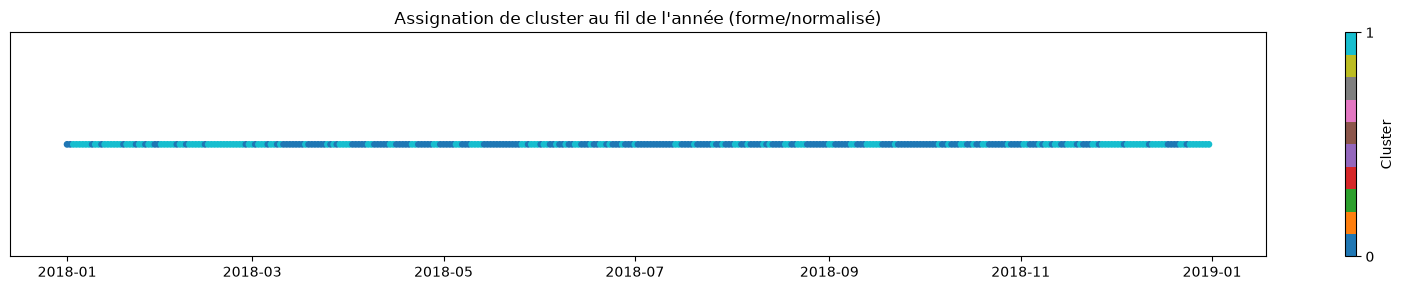

In [24]:
results_sorted = results_amplet.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 3))
scatter = ax.scatter(results_sorted["date"], [1]*len(results_sorted),
                      c=results_sorted["cluster"], cmap="tab10", s=15)
ax.set_yticks([])
ax.set_title("Assignation de cluster au fil de l'année (amplitude/brut)")
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(k_amplet))
plt.tight_layout()
plt.savefig(FIGURES / "cluster_timeline.png", dpi=150)
plt.show()


results_sorted = results_forme.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 3))
scatter = ax.scatter(results_sorted["date"], [1]*len(results_sorted),
                      c=results_sorted["cluster"], cmap="tab10", s=15)
ax.set_yticks([])
ax.set_title("Assignation de cluster au fil de l'année (forme/normalisé)")
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(k_forme))
plt.tight_layout()
plt.savefig(FIGURES / "cluster_timeline.png", dpi=150)
plt.show()

Visualisation des clusters de données AVEC PCA

k= 2 | inertia=    4022.5 | silhouette=0.1067
k= 3 | inertia=    3805.6 | silhouette=0.0826
k= 4 | inertia=    3644.8 | silhouette=0.0856
k= 5 | inertia=    3499.4 | silhouette=0.0747
k= 6 | inertia=    3374.2 | silhouette=0.0863
k= 7 | inertia=    3237.6 | silhouette=0.0819
k= 8 | inertia=    3110.4 | silhouette=0.0846
k= 9 | inertia=    3033.0 | silhouette=0.0692
k=10 | inertia=    2952.6 | silhouette=0.0782
k=11 | inertia=    2870.0 | silhouette=0.0626
k=12 | inertia=    2789.6 | silhouette=0.0788
k=13 | inertia=    2696.1 | silhouette=0.0798
k=14 | inertia=    2649.8 | silhouette=0.0883
K optimal selon la méthode du coude : k = 8


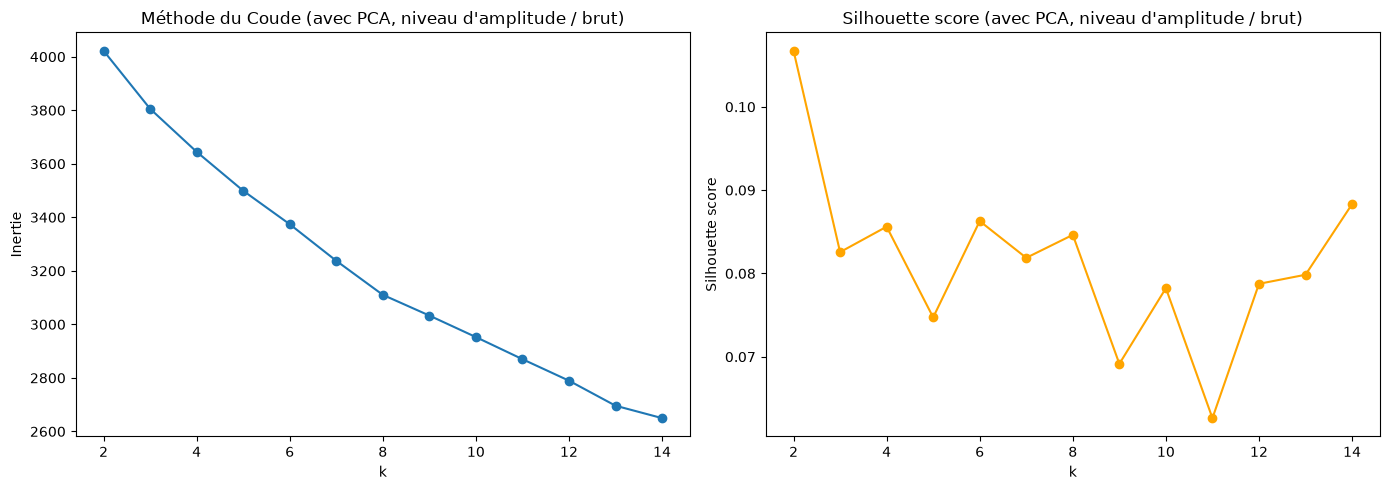

In [39]:
k_xpca=plot_cluster_profiles(x_pca, "Méthode du Coude (avec PCA, niveau d'amplitude / brut)", "Silhouette score (avec PCA, niveau d'amplitude / brut)")

In [26]:
kmeans_xpca, cluster_labels_xpca, results_xpca = cluster_days(k_xpca, x_pca,piv.index)
results_xpca

Répartition des données pour k=8
cluster
0     30
1     39
2    119
3     26
4     48
5     36
6     41
7     26
Name: count, dtype: int64


,date,cluster,weekday,is_weekend,month
0,2018-01-01,2,Monday,False,1
1,2018-01-02,1,Tuesday,False,1
2,2018-01-03,5,Wednesday,False,1
3,2018-01-04,1,Thursday,False,1
4,2018-01-05,0,Friday,False,1
...,...,...,...,...,...
360,2018-12-27,4,Thursday,False,12
361,2018-12-28,5,Friday,False,12
362,2018-12-29,4,Saturday,True,12
363,2018-12-30,0,Sunday,True,12


In [27]:
print("PCA sur données brutes")
plot_interactive_cluster_profiles(
    X=x_pca,
    cluster_labels=cluster_labels_xpca,
    k_final=k_xpca,
    titre="Profil journalier par rapport à la quantité d'énergie consommée (PCA sur données brutes / niveau d'amplitude)"
)

PCA sur données brutes


PCA SUR DONNEES BRUTES
Répartition semaine / weekend :
         Semaine (%)  Weekend (%)
cluster                          
0               66.7         33.3
1               61.5         38.5
2               82.4         17.6
3               65.4         34.6
4               39.6         60.4
5               83.3         16.7
6               85.4         14.6
7               69.2         30.8



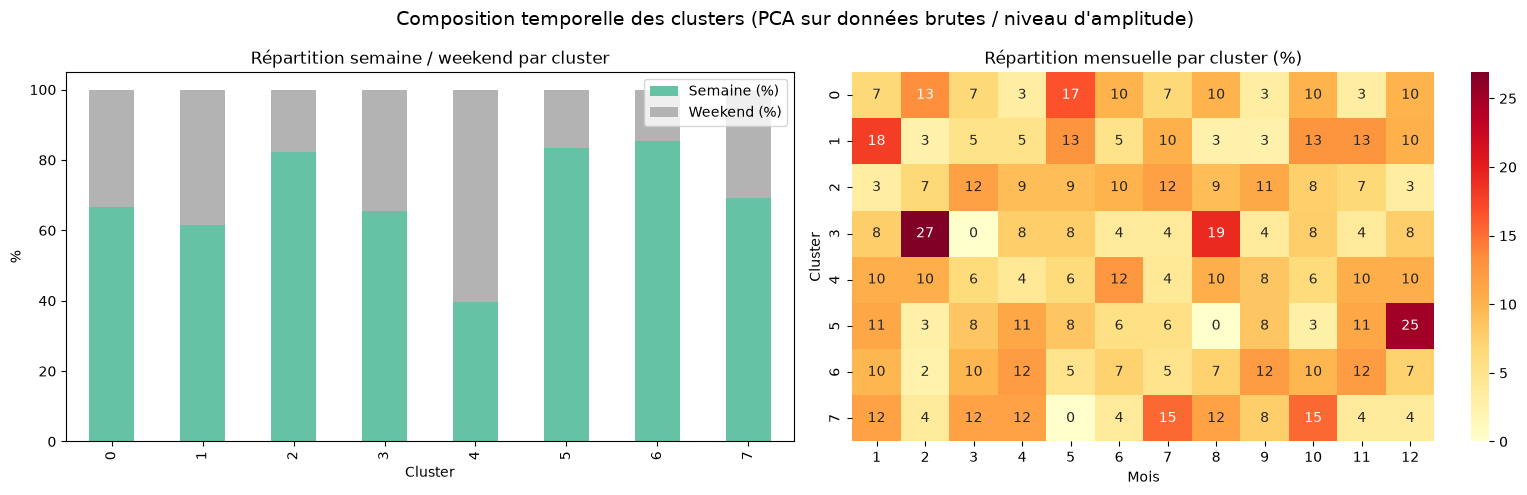

(         Semaine (%)  Weekend (%)
 cluster                          
 0          66.666667    33.333333
 1          61.538462    38.461538
 2          82.352941    17.647059
 3          65.384615    34.615385
 4          39.583333    60.416667
 5          83.333333    16.666667
 6          85.365854    14.634146
 7          69.230769    30.769231,
 month           1          2          3          4          5          6   \
 cluster                                                                     
 0         6.666667  13.333333   6.666667   3.333333  16.666667  10.000000   
 1        17.948718   2.564103   5.128205   5.128205  12.820513   5.128205   
 2         3.361345   6.722689  11.764706   9.243697   9.243697  10.084034   
 3         7.692308  26.923077   0.000000   7.692308   7.692308   3.846154   
 4        10.416667  10.416667   6.250000   4.166667   6.250000  12.500000   
 5        11.111111   2.777778   8.333333  11.111111   8.333333   5.555556   
 6         9.756098   2.4

In [28]:
print("PCA SUR DONNEES BRUTES")
plot_cluster_calendar_composition(results_xpca, "Composition temporelle des clusters (PCA sur données brutes / niveau d'amplitude)")

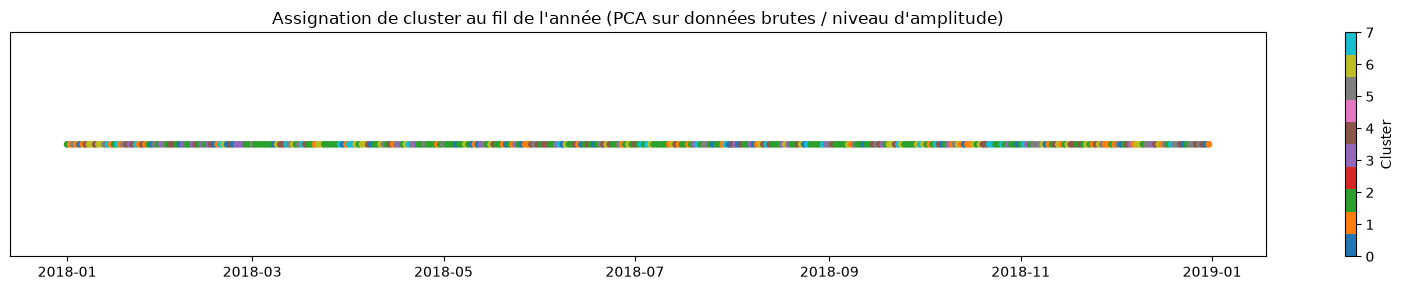

In [29]:
results_sorted = results_xpca.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 3))
scatter = ax.scatter(results_sorted["date"], [1]*len(results_sorted),
                      c=results_sorted["cluster"], cmap="tab10", s=15)
ax.set_yticks([])
ax.set_title("Assignation de cluster au fil de l'année (PCA sur données brutes / niveau d'amplitude)")
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(k_xpca))
plt.tight_layout()
plt.savefig(FIGURES / "cluster_timeline.png", dpi=150)
plt.show()

k= 2 | inertia=    7896.8 | silhouette=0.0652
k= 3 | inertia=    7562.9 | silhouette=0.0510
k= 4 | inertia=    7300.3 | silhouette=0.0346
k= 5 | inertia=    7097.1 | silhouette=0.0390
k= 6 | inertia=    6902.8 | silhouette=0.0399
k= 7 | inertia=    6724.4 | silhouette=0.0417
k= 8 | inertia=    6555.0 | silhouette=0.0384
k= 9 | inertia=    6377.3 | silhouette=0.0439
k=10 | inertia=    6202.5 | silhouette=0.0530
k=11 | inertia=    6100.2 | silhouette=0.0424
k=12 | inertia=    6018.6 | silhouette=0.0529
k=13 | inertia=    5859.0 | silhouette=0.0552
k=14 | inertia=    5739.9 | silhouette=0.0337
K optimal selon la méthode du coude : k = 6


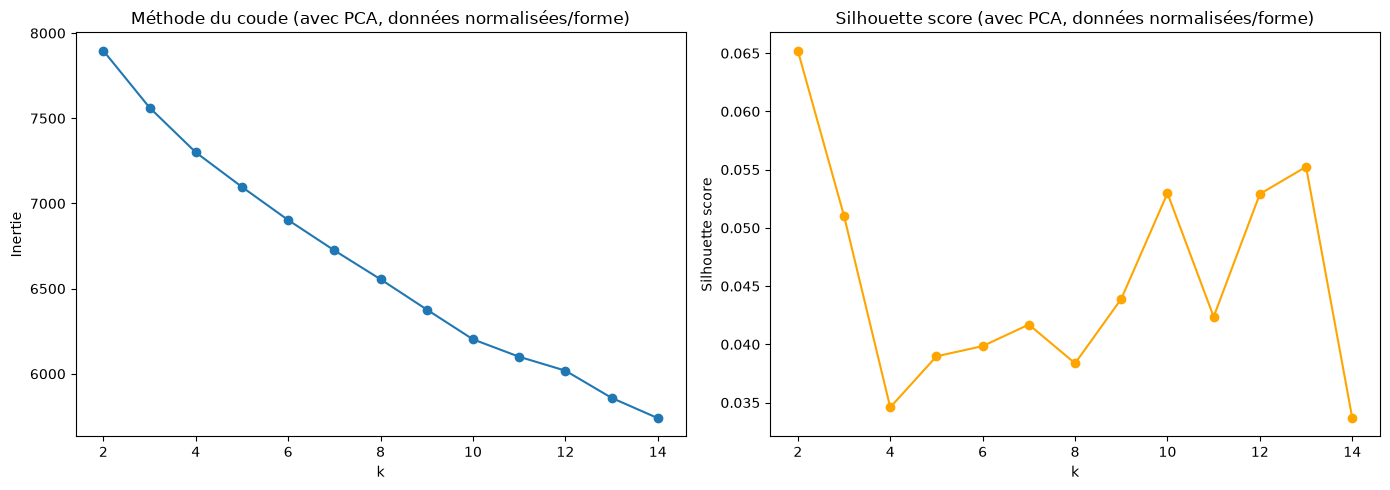

In [41]:
k_Xpca=plot_cluster_profiles(X_pca, "Méthode du coude (avec PCA, données normalisées/forme)", "Silhouette score (avec PCA, données normalisées/forme)")

In [31]:
kmeans_Xpca, cluster_labels_Xpca, results_Xpca = cluster_days(k_Xpca, X_pca,piv.index)
results_Xpca

Répartition des données pour k=6
cluster
0     20
1     84
2     18
3     89
4     45
5    109
Name: count, dtype: int64


,date,cluster,weekday,is_weekend,month
0,2018-01-01,5,Monday,False,1
1,2018-01-02,3,Tuesday,False,1
2,2018-01-03,4,Wednesday,False,1
3,2018-01-04,1,Thursday,False,1
4,2018-01-05,1,Friday,False,1
...,...,...,...,...,...
360,2018-12-27,4,Thursday,False,12
361,2018-12-28,4,Friday,False,12
362,2018-12-29,1,Saturday,True,12
363,2018-12-30,5,Sunday,True,12


In [32]:
print("PCA sur données normalisées")
plot_interactive_cluster_profiles(
    X=X_pca,
    cluster_labels=cluster_labels_Xpca,
    k_final=k_Xpca,
    titre="Profil journalier par rapport à la quantité d'énergie consommée (PCA sur données normalisées / forme)"
)

PCA sur données normalisées


PCA SUR DONNEES NORMALISEES
Répartition semaine / weekend :
         Semaine (%)  Weekend (%)
cluster                          
0               55.0         45.0
1               46.4         53.6
2              100.0          0.0
3               86.5         13.5
4               62.2         37.8
5               80.7         19.3



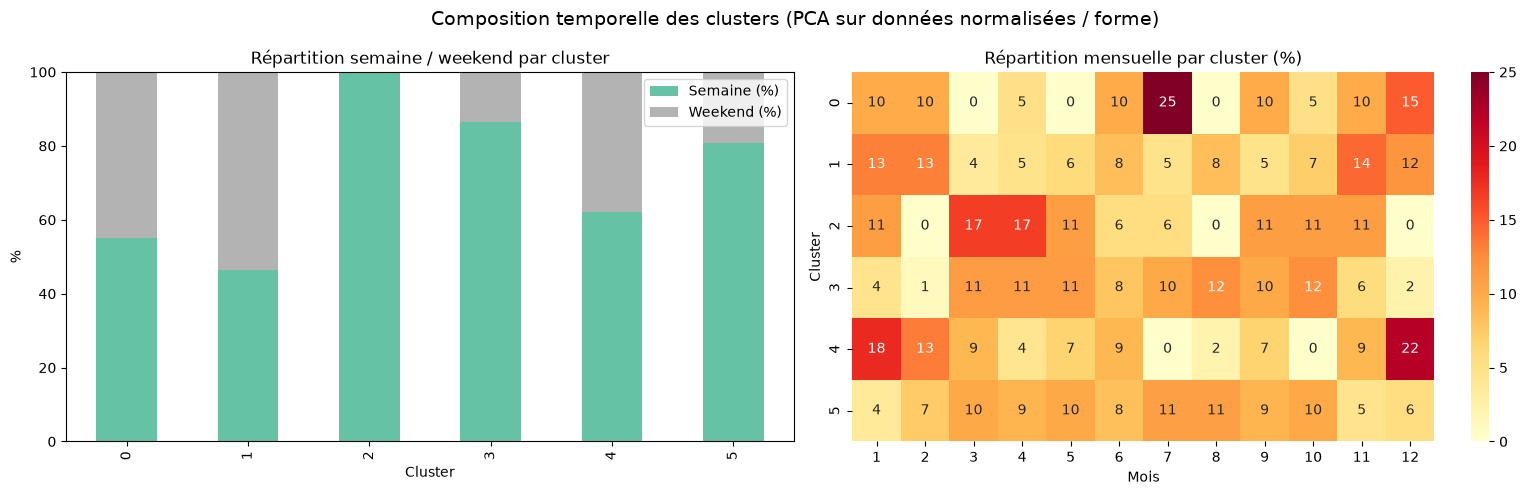

(         Semaine (%)  Weekend (%)
 cluster                          
 0          55.000000    45.000000
 1          46.428571    53.571429
 2         100.000000     0.000000
 3          86.516854    13.483146
 4          62.222222    37.777778
 5          80.733945    19.266055,
 month           1          2          3          4          5          6   \
 cluster                                                                     
 0        10.000000  10.000000   0.000000   5.000000   0.000000  10.000000   
 1        13.095238  13.095238   3.571429   4.761905   5.952381   8.333333   
 2        11.111111   0.000000  16.666667  16.666667  11.111111   5.555556   
 3         4.494382   1.123596  11.235955  11.235955  11.235955   7.865169   
 4        17.777778  13.333333   8.888889   4.444444   6.666667   8.888889   
 5         3.669725   7.339450  10.091743   9.174312  10.091743   8.256881   
 
 month           7          8          9          10         11         12  
 cluster        

In [33]:
print("PCA SUR DONNEES NORMALISEES")
plot_cluster_calendar_composition(results_Xpca, "Composition temporelle des clusters (PCA sur données normalisées / forme)")

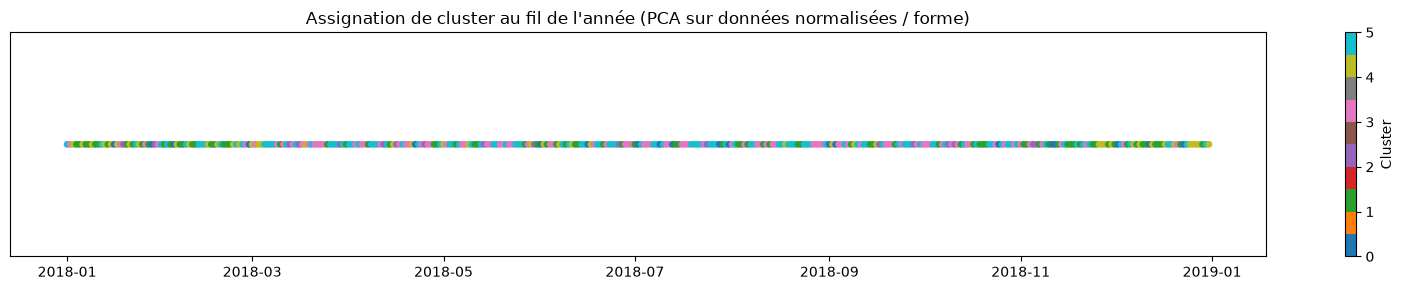

In [34]:
results_sorted = results_Xpca.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 3))
scatter = ax.scatter(results_sorted["date"], [1]*len(results_sorted),
                      c=results_sorted["cluster"], cmap="tab10", s=15)
ax.set_yticks([])
ax.set_title("Assignation de cluster au fil de l'année (PCA sur données normalisées / forme)")
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(k_Xpca))
plt.tight_layout()
plt.savefig(FIGURES / "cluster_timeline.png", dpi=150)
plt.show()